In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the MovieLens 100K data
ratings = pd.read_csv('../data/raw/ml-100k/u.data', 
                       sep='\t', 
                       names=['user_id', 'movie_id', 'rating', 'timestamp'])

movies = pd.read_csv('../data/raw/ml-100k/u.item',
                      sep='|',
                      encoding='latin-1',
                      usecols=[0, 1],
                      names=['movie_id', 'title'])

print(ratings.shape)
print(ratings.head())

(100000, 4)
   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596


In [2]:
print(ratings.info())
print(ratings.describe())
print("\nMissing values:", ratings.isnull().sum().sum())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None
            user_id       movie_id         rating     timestamp
count  100000.00000  100000.000000  100000.000000  1.000000e+05
mean      462.48475     425.530130       3.529860  8.835289e+08
std       266.61442     330.798356       1.125674  5.343856e+06
min         1.00000       1.000000       1.000000  8.747247e+08
25%       254.00000     175.000000       3.000000  8.794487e+08
50%       447.00000     322.000000       4.000000  8.828269e+08
75%       682.00000     631.000000       4.000000  8.882600e+08
max       943.00000    1682.000000       5.000000  8.932866e+08

Missing values: 0


In [3]:
df = ratings.merge(movies, on='movie_id')
print(df.head())
print(df.shape)

   user_id  movie_id  rating  timestamp                       title
0      196       242       3  881250949                Kolya (1996)
1      186       302       3  891717742    L.A. Confidential (1997)
2       22       377       1  878887116         Heavyweights (1994)
3      244        51       2  880606923  Legends of the Fall (1994)
4      166       346       1  886397596         Jackie Brown (1997)
(100000, 5)


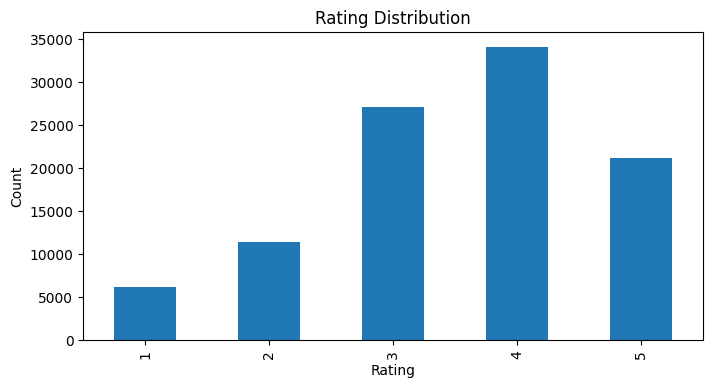

In [4]:
plt.figure(figsize=(8, 4))
ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [5]:
top_movies = df.groupby('title')['rating'].agg(['count', 'mean']).sort_values('count', ascending=False).head(10)
top_movies.columns = ['num_ratings', 'avg_rating']
print(top_movies)

                               num_ratings  avg_rating
title                                                 
Star Wars (1977)                       583    4.358491
Contact (1997)                         509    3.803536
Fargo (1996)                           508    4.155512
Return of the Jedi (1983)              507    4.007890
Liar Liar (1997)                       485    3.156701
English Patient, The (1996)            481    3.656965
Scream (1996)                          478    3.441423
Toy Story (1995)                       452    3.878319
Air Force One (1997)                   431    3.631090
Independence Day (ID4) (1996)          429    3.438228


In [6]:
movie_stats = df.groupby('title')['rating'].agg(['count', 'mean'])
movie_stats.columns = ['num_ratings', 'avg_rating']
popular_movies = movie_stats[movie_stats['num_ratings'] >= 50].sort_values('avg_rating', ascending=False)
print(popular_movies.head(10))

                                                    num_ratings  avg_rating
title                                                                      
Close Shave, A (1995)                                       112    4.491071
Schindler's List (1993)                                     298    4.466443
Wrong Trousers, The (1993)                                  118    4.466102
Casablanca (1942)                                           243    4.456790
Wallace & Gromit: The Best of Aardman Animation...           67    4.447761
Shawshank Redemption, The (1994)                            283    4.445230
Rear Window (1954)                                          209    4.387560
Usual Suspects, The (1995)                                  267    4.385768
Star Wars (1977)                                            583    4.358491
12 Angry Men (1957)                                         125    4.344000
